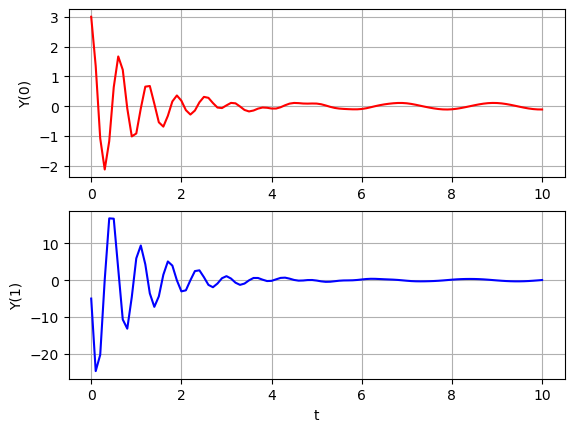

 < error> =   2.956865652360389e-07
flops =  452


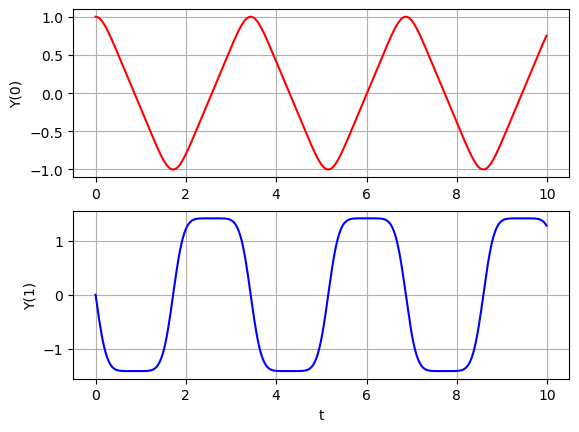

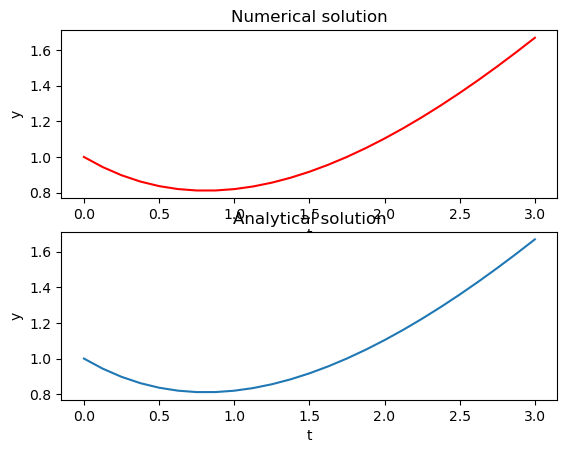

In [2]:
%run CP08.ipynb

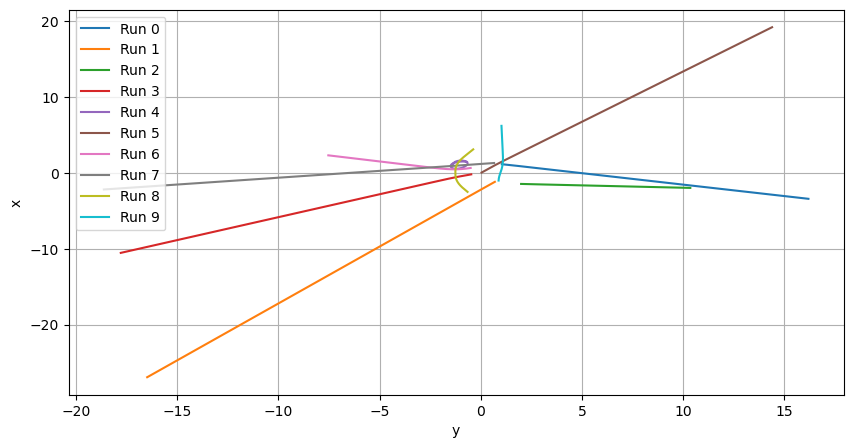

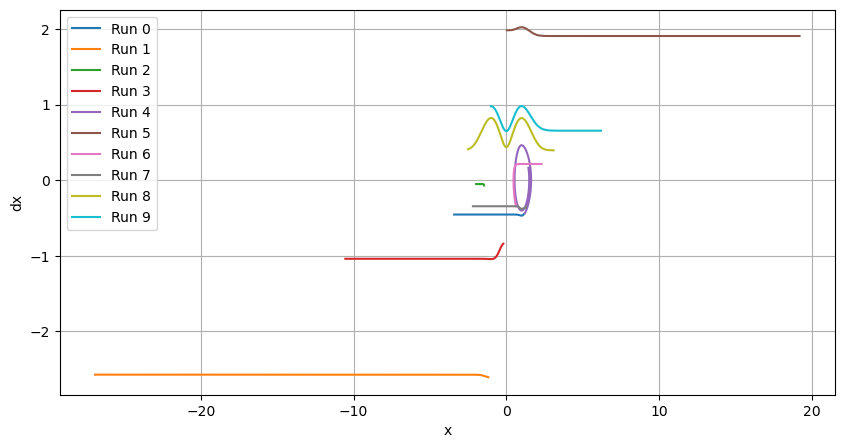

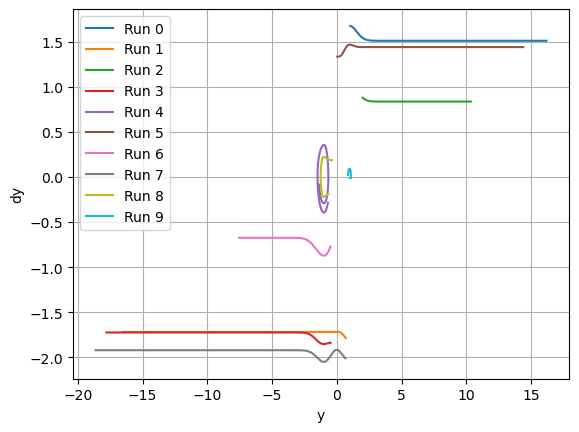

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def f(t, state):
    x, y, dx, dy = state

    f0 = dx
    f1 = dy

    f2 = sgn * (1/m) * 2*y**2 * x * (1 - x**2) * np.exp(-(x**2 + y**2))
    f3 = sgn * (1/m) * 2*x**2 * y * (1 - y**2) * np.exp(-(x**2 + y**2))

    return np.array([f0, f1, f2, f3])





arrays = {}

N = 1000
sgn = +1
m = 0.5
dt = 0.01

for i in range(10):

    # One random initial condition per run
    x0 = np.random.randn()
    y0 = np.random.randn()
    dx0 = np.random.randn()
    dy0 = np.random.randn()

    # State has shape (time, variables)
    arrays[f"state{i}"] = np.zeros((N+1, 4))

    arrays[f"state{i}"][0] = np.array([
        x0,
        y0,
        dx0,
        dy0
    ])

    rk4(0, arrays[f"state{i}"], dt)


# Plot
plt.figure(figsize=(10, 5))

for i, arr in enumerate(arrays.values()):
    plt.plot(arr[:, 1], arr[:, 0], label=f"Run {i}")

plt.xlabel("y")
plt.ylabel("x")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))

for i, arr in enumerate(arrays.values()):
    plt.plot(arr[:, 0], arr[:, 2], label=f"Run {i}")

plt.xlabel("x")
plt.ylabel("dx")
plt.legend()
plt.grid(True)
plt.show()

for i, arr in enumerate(arrays.values()):
    plt.plot(arr[:, 1], arr[:, 3], label=f"Run {i}")

plt.xlabel("y")
plt.ylabel("dy")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_116885/1560878329.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


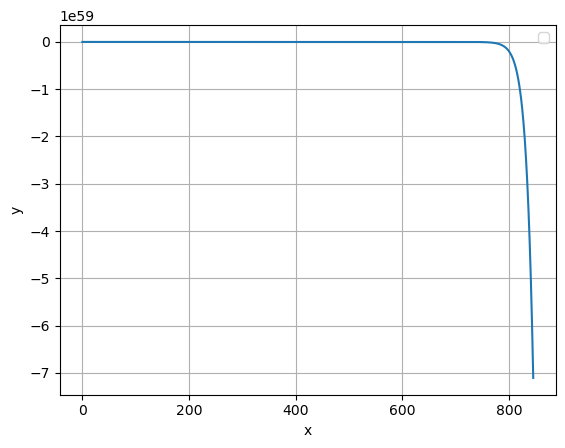

In [4]:
import numpy as np
import matplotlib.pyplot as plt
def rk4(t, y, h1):                  # function for rk4 init
    for i in range(0, N):
        t  = h1 * i
        k0 = h1 * f( t, y[i] )
        k1 = h1 * f( t + h1/2., y[i] + k0/2. )
        k2 = h1 * f( t + h1/2., y[i] + k1/2. )
        k3 = h1 * f( t + h1, y[i] + k2 )
        y[i + 1] = y[i]  +  (1./6.) * (k0  +  2.*k1  +  2.*k2 + k3)
    return y[3]

def f(t, state):
    x, y, dx, dy = state

    f0 = dx / dy
    f1 = 1/m*F_x(dx, dy, dt, m, k, n)

    f2 = dy / dt
    f3 = 1/m*F_y(dx, dy, dt, m, k, n) - g

    return np.array([f0, f1, f2, f3])

def F_x(dx, dy, dt, m, k, n):
    dx_dt = dx / dt
    dy_dt = dy / dt
    F = m*(-k*dx_dt**n*dx_dt/(np.sqrt(dx_dt**2 + dy_dt**2)))
    return F
def F_y(dx, dy, dt, m, k, n):
    dx_dt = dx / dt
    dy_dt = dy / dt
    F = m*(-g-k*dy_dt**n*dy_dt/(np.sqrt(dx_dt**2 + dy_dt**2))) + m*g
    return F

# parameters
m = 1
x0 = 0
y0 = 0
dx0 = 1
dy0 = 1
dt = 0.1
N = 1000
k = 1
n = 1
g =9.8
arrays= np.zeros((N+1, 4))

arrays[0] = np.array([
        x0,
        y0,
        dx0,
        dy0
    ])

rk4(0, arrays, dt)

plt.plot(arrays[:, 0], arrays[:, 1])

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def rk4(t, y, h1):                  # function for rk4 init
    for i in range(0, N):
        t  = h1 * i
        k0 = h1 * f( t, y[i] )
        k1 = h1 * f( t + h1/2., y[i] + k0/2. )
        k2 = h1 * f( t + h1/2., y[i] + k1/2. )
        k3 = h1 * f( t + h1, y[i] + k2 )
        y[i + 1] = y[i]  +  (1./6.) * (k0  +  2.*k1  +  2.*k2 + k3)
    return y[3]

def f(dt, state):
    x, y, dx, dy = state

    f0 = -x*dt/r(x,y)**3
    f1 = -x/r(x,y)**3

    f2 = -y*dt/r(x,y)**3
    f3 = -y/r(x,y)**3

    return np.array([f0, f1, f2, f3])

def r(x,y):
    return np.sqrt(x**2 + y**2)
# parameters
dt = 0.0001
x0 = 0.5
y0 = 0
dx0 = 1
dy0 = 1.63*dt

N = 1000

arrays= np.zeros((N+1, 4))

arrays[0] = np.array([
        x0,
        y0,
        dx0,
        dy0
    ])

rk4(0, arrays, dt)
time_array = []

for i in range(N+1):
    time_array = np.append(time_array,dt*i)

plt.plot(time_array, arrays[:,0])

plt.xlabel("t")
plt.ylabel("x")
plt.legend()
plt.grid(True)
plt.show()